
### Import Libraries


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import statsmodels.api as sm


### Load Data


In [3]:
df=pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Credit Risk Model\loan.csv', low_memory=False)
print(df.shape)

(2260668, 145)


### Target Variable

In [4]:

df = df[df['loan_status'].isin([
    'Fully Paid','Charged Off','Default'
])]

df['target'] = np.where(
    df['loan_status'].isin(['Charged Off','Default']),1,0
)

### Remove Data Leakage Variables

In [5]:
leakage_cols = [

'id','member_id','url','zip_code',

'out_prncp','out_prncp_inv',

'total_pymnt','total_pymnt_inv',

'total_rec_prncp','total_rec_int',

'total_rec_late_fee','recoveries',

'collection_recovery_fee',

'last_pymnt_d','last_pymnt_amnt',

'collections_12_mths_ex_med',

'policy_code','acc_now_delinq',

'delinq_amnt','last_credit_pull_d',

'loan_status'
]

df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

### Remove High Missing Columns

In [6]:
missing_ratio = df.isnull().mean()

drop_cols = missing_ratio[missing_ratio>0.7].index

df = df.drop(columns=drop_cols)

print("Remaining variables:",df.shape[1])



Remaining variables: 86


### Train / Validation Split

In [7]:
X = df.drop('target',axis=1)
y = df['target']

X_train,X_val,y_train,y_val = train_test_split(

    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

train_df = pd.concat([X_train,y_train],axis=1)
val_df = pd.concat([X_val,y_val],axis=1)

print(train_df.shape,val_df.shape)

(912546, 86) (391092, 86)


### Missing Value Treatment

In [8]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('target')

cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    val_df[col] = val_df[col].fillna(train_df[col].median())

for col in cat_cols:
    train_df[col] = train_df[col].fillna("Missing")
    val_df[col] = val_df[col].fillna("Missing")

### Target Distribution

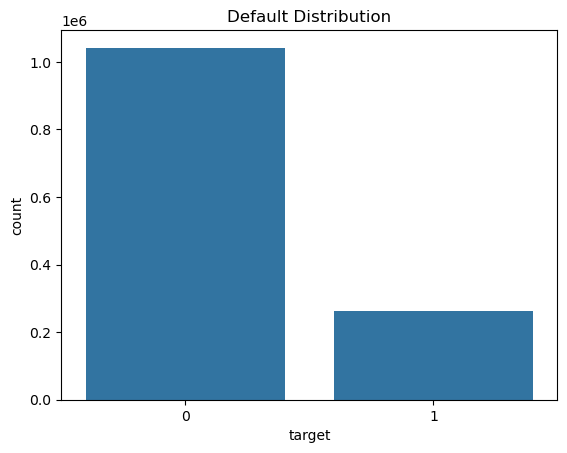

In [9]:
sns.countplot(x='target', data=df)

plt.title("Default Distribution")

plt.show()


### Default Percentage Pie Chart

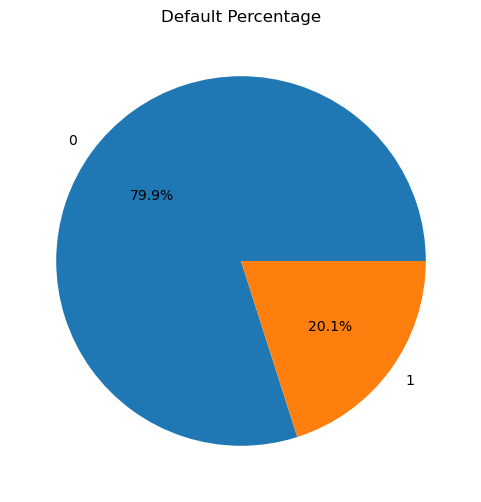

In [10]:
df['target'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Default Percentage"
)
plt.ylabel("")
plt.show()

### Random Forest Feature Selection (TRAIN ONLY)

In [11]:
rf_train = train_df.copy()

# simple encoding for RF
for col in cat_cols:
    rf_train[col] = rf_train[col].astype('category').cat.codes

X_rf = rf_train.drop('target',axis=1)
y_rf = rf_train['target']

rf = RandomForestClassifier(

    n_estimators=300,
    max_depth=10,
    min_samples_leaf=50,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_rf,y_rf)

importance = pd.DataFrame({

"variable":X_rf.columns,
"importance":rf.feature_importances_

}).sort_values(by='importance',ascending=False)

top30 = importance.head(30)['variable'].tolist()

print("Top variables:",top30)


Top variables: ['debt_settlement_flag', 'sub_grade', 'grade', 'int_rate', 'term', 'dti', 'tot_hi_cred_lim', 'avg_cur_bal', 'acc_open_past_24mths', 'verification_status', 'mort_acc', 'funded_amnt_inv', 'loan_amnt', 'tot_cur_bal', 'funded_amnt', 'bc_open_to_buy', 'all_util', 'installment', 'open_rv_24m', 'home_ownership', 'annual_inc', 'total_bc_limit', 'num_tl_op_past_12m', 'max_bal_bc', 'mo_sin_old_rev_tl_op', 'num_actv_rev_tl', 'emp_length', 'num_rev_tl_bal_gt_0', 'total_rev_hi_lim', 'revol_util']


### Dataset with Selected Variables

In [12]:
train_df = train_df[top30 + ['target']]
val_df = val_df[top30 + ['target']]

num_cols = train_df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('target')

cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

### Correlation Removal

In [13]:

corr = train_df[num_cols].corr()

upper = corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))

high_corr = [

c for c in upper.columns
if any(upper[c]>0.7)

]

train_df = train_df.drop(columns=high_corr)
val_df = val_df.drop(columns=high_corr)

num_cols = [c for c in num_cols if c not in high_corr]

### Default Rate by Numerical Variable 

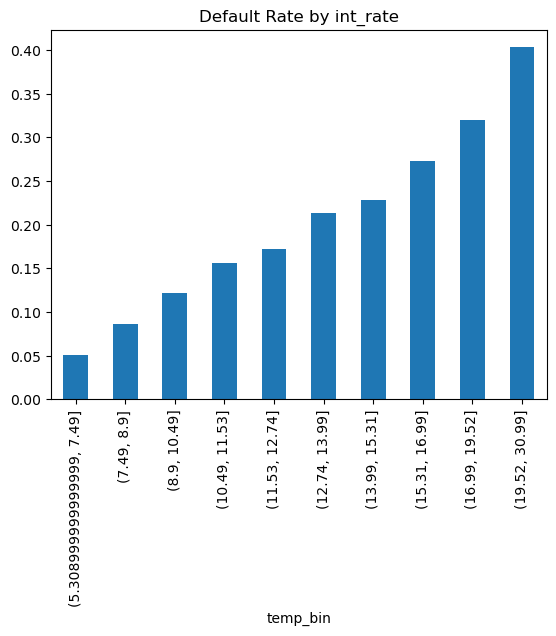

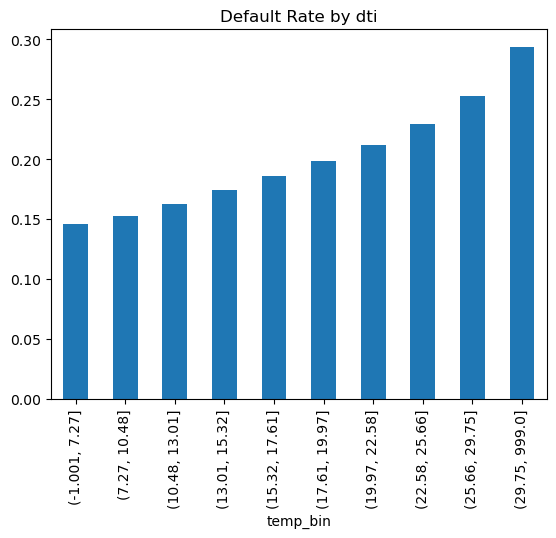

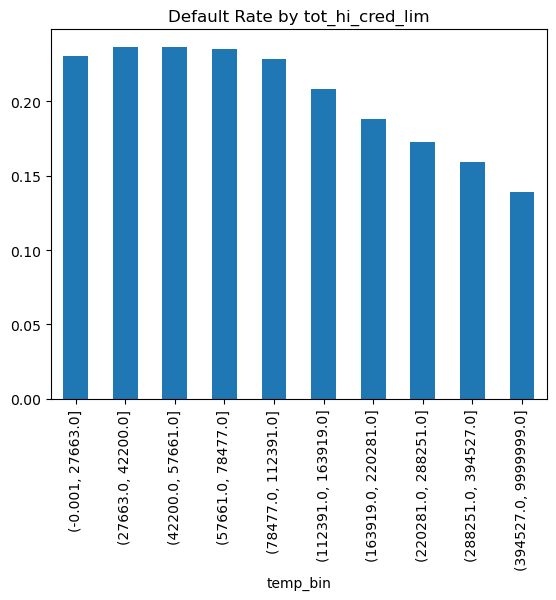

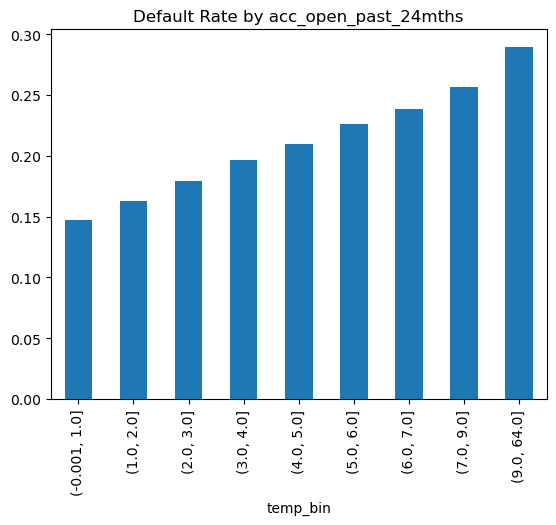

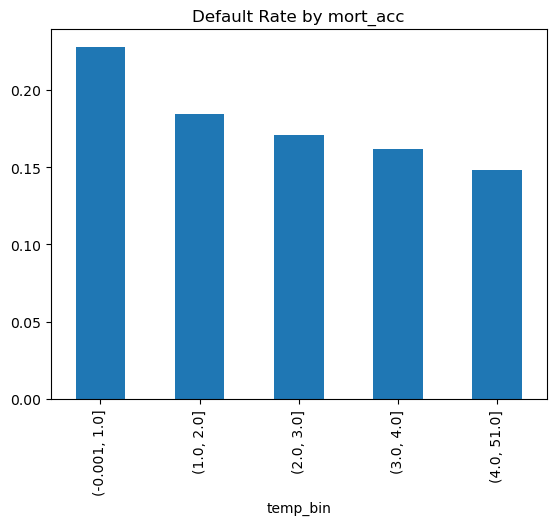

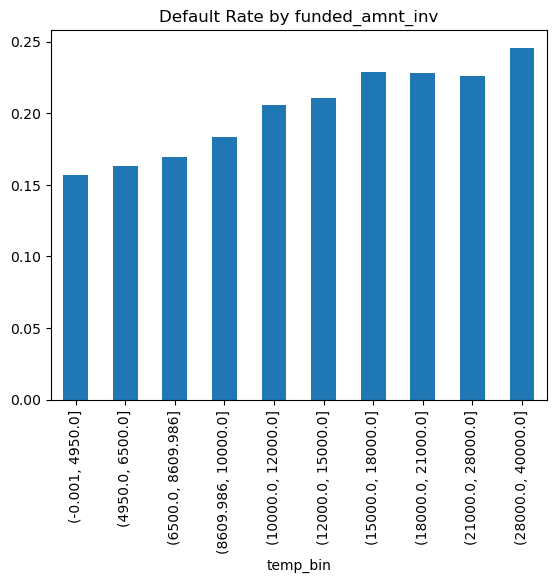

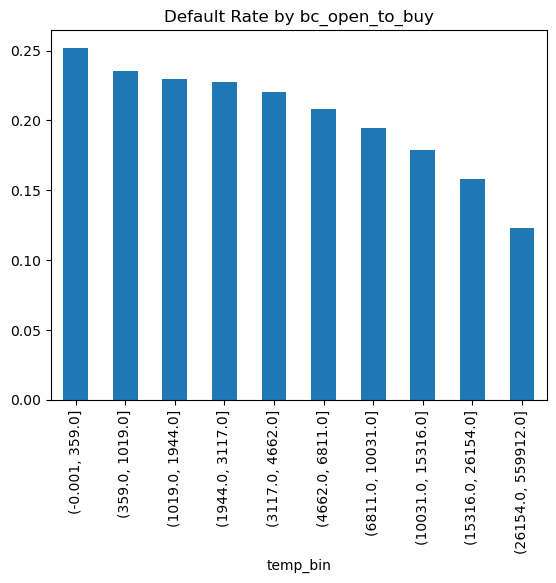

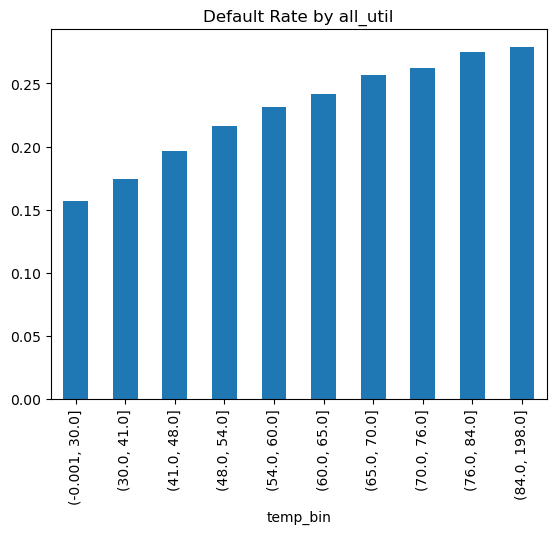

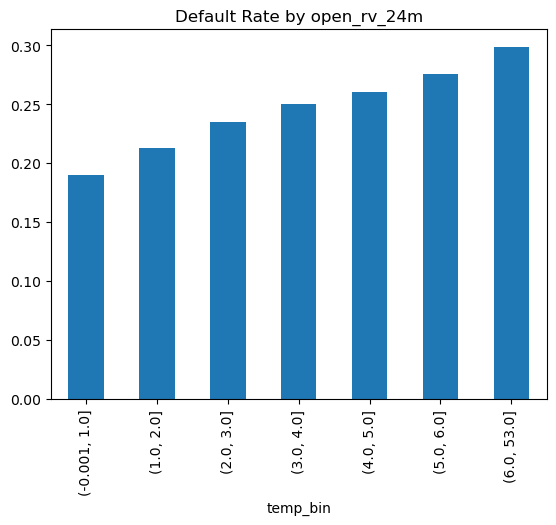

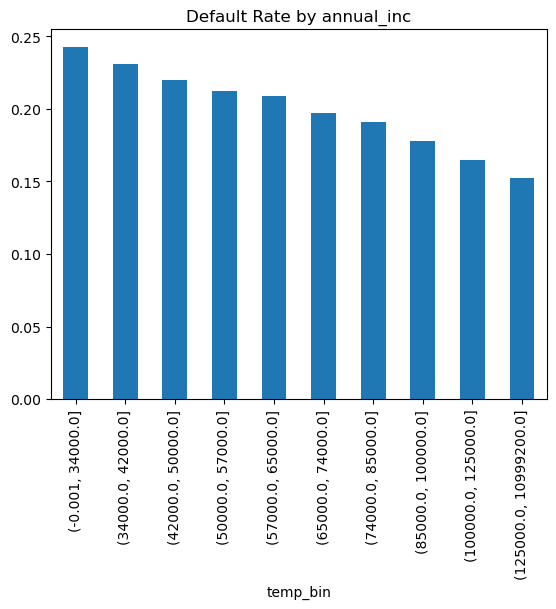

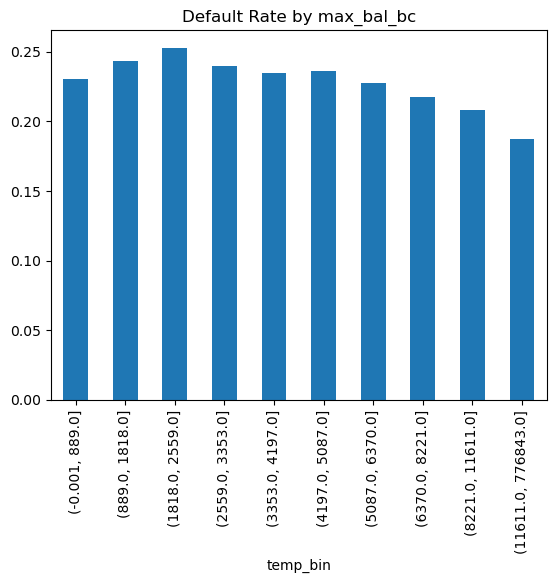

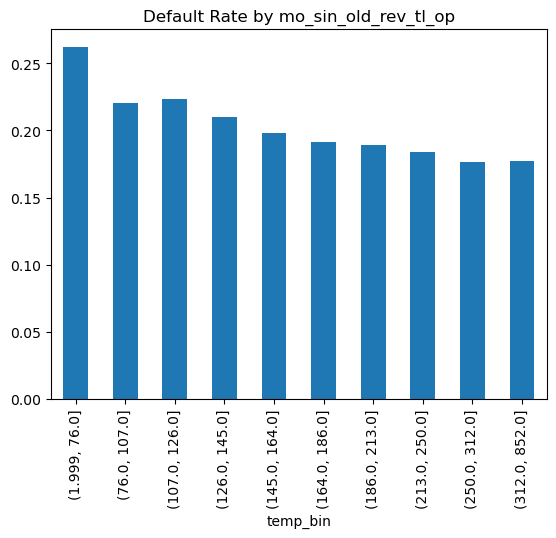

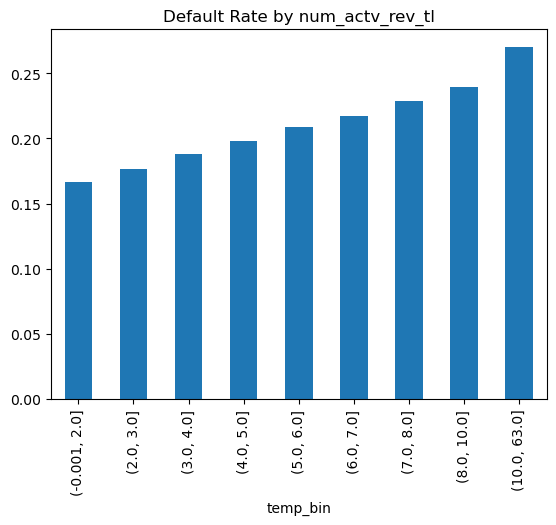

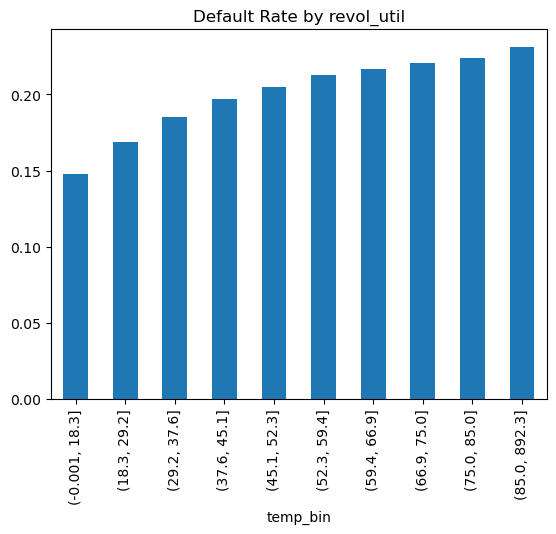

In [14]:
for col in num_cols:

    df['temp_bin'] = pd.qcut(df[col],10,duplicates='drop')

    default_rate = df.groupby('temp_bin')['target'].mean()

    default_rate.plot(kind='bar')

    plt.title(f"Default Rate by {col}")

    plt.show()

### Default Rate by Categorical Variable

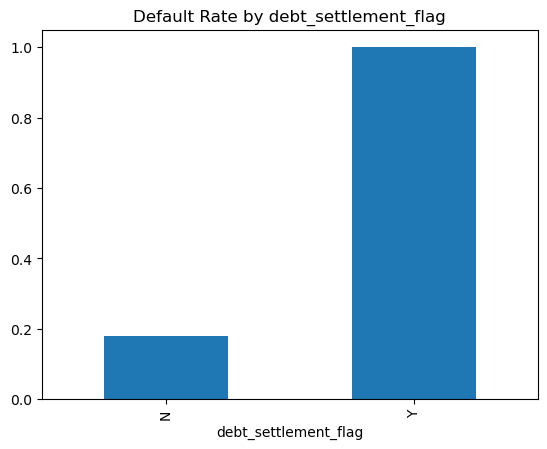

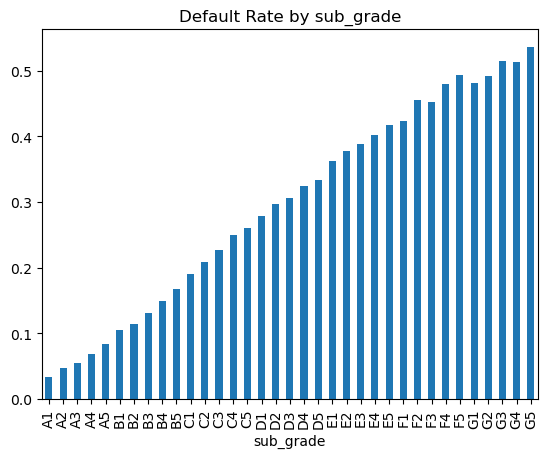

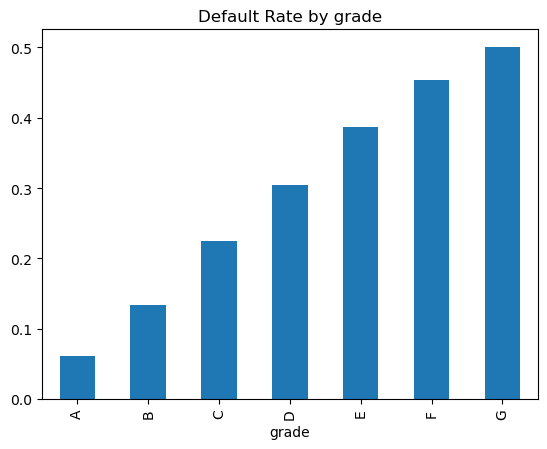

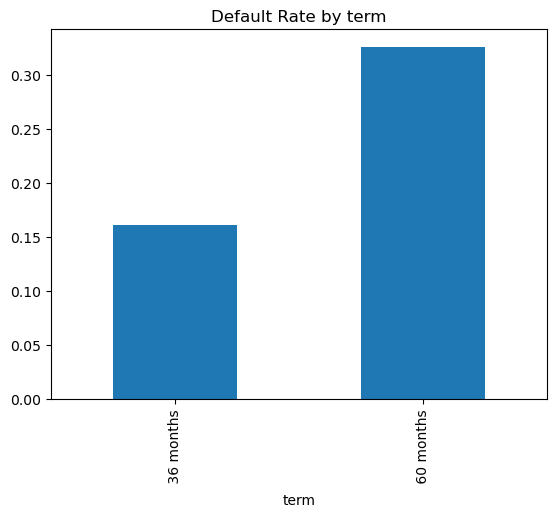

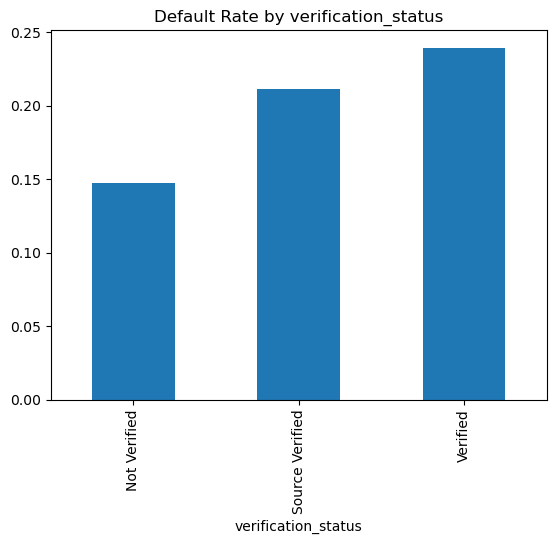

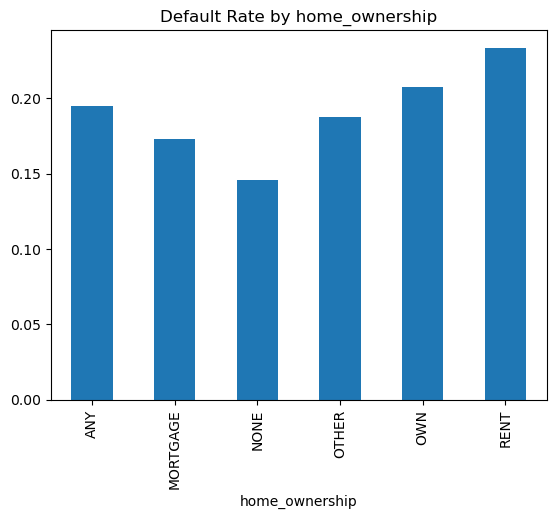

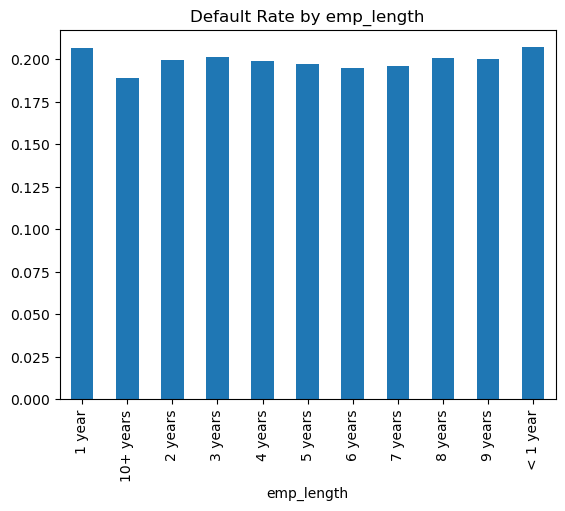

In [15]:
for col in cat_cols:

    default_rate = df.groupby(col)['target'].mean()

    default_rate.plot(kind='bar')

    plt.title(f"Default Rate by {col}")

    plt.show()

### WOE Binning

In [16]:
def woe_iv(data,feature,target):

    table = pd.crosstab(data[feature],data[target])

    table.columns=["Good","Bad"]

    table["Good"]+=0.5
    table["Bad"]+=0.5

    table["Dist_Good"]=table["Good"]/table["Good"].sum()
    table["Dist_Bad"]=table["Bad"]/table["Bad"].sum()

    table["WOE"]=np.log(table["Dist_Good"]/table["Dist_Bad"])

    table["IV"]=(table["Dist_Good"]-table["Dist_Bad"])*table["WOE"]

    iv = table["IV"].sum()

    return table,iv

### Numerical Binning

In [17]:
for col in num_cols:

    train_df[col+"_bin"] = pd.qcut(

        train_df[col],
        10,
        duplicates='drop'
    )

    val_df[col+"_bin"] = pd.cut(

        val_df[col],
        bins=train_df[col+"_bin"].cat.categories
    )


### Monotonic Bining of the Numerical Variable

In [18]:
from scipy.stats import spearmanr


def monotonic_binning(df, variable, target, max_bins=20):

    df2 = df[[variable, target]].copy()
    df2 = df2.dropna()

    r = 0
    bins = max_bins

    while abs(r) < 1 and bins > 2:

        try:

            df2['bin'] = pd.qcut(df2[variable], bins, duplicates='drop')

            grouped = df2.groupby('bin')

            mean_x = grouped[variable].mean()
            mean_y = grouped[target].mean()

            r, _ = spearmanr(mean_x, mean_y)

            bins -= 1

        except:
            bins -= 1

    return df2['bin'], bins


# Apply Monotonic Binning

binning_dict = {}

for col in num_cols:

    train_df[col+"_bin"], bins = monotonic_binning(
        train_df,
        col,
        'target'
    )

    # store bin edges for validation
    bin_edges = train_df[col+"_bin"].cat.categories

    binning_dict[col] = bin_edges

    val_df[col+"_bin"] = pd.cut(
        val_df[col],
        bins=bin_edges
    )

### Visualize Monotonic Default Rate

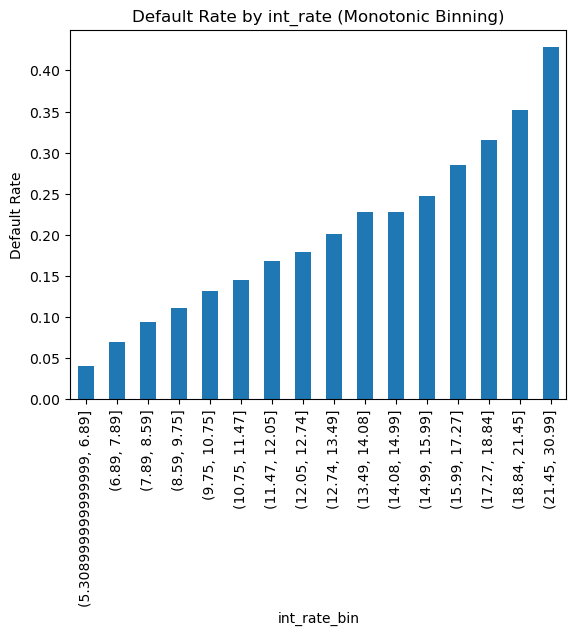

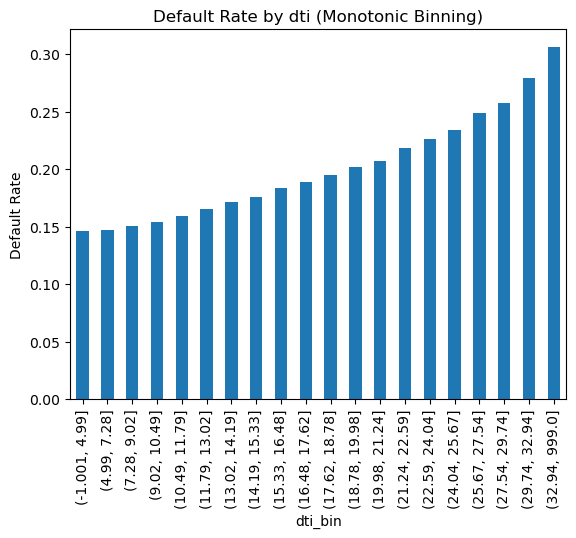

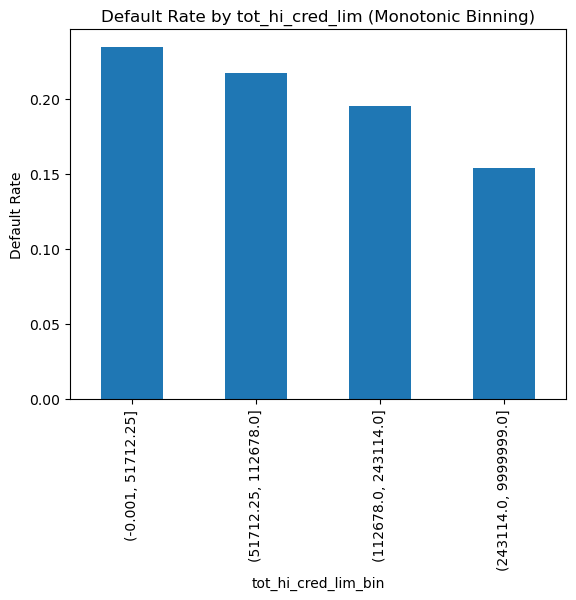

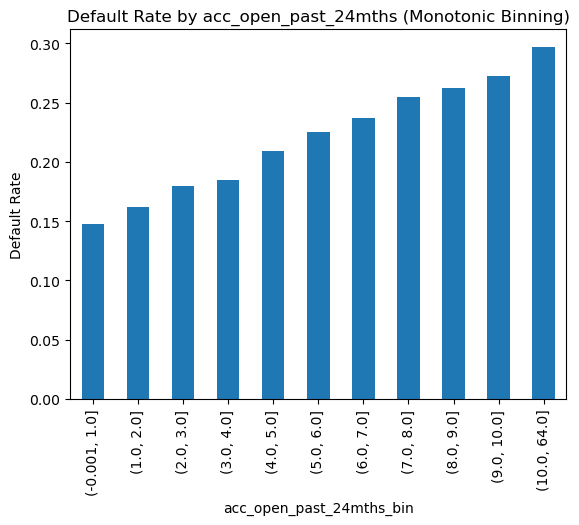

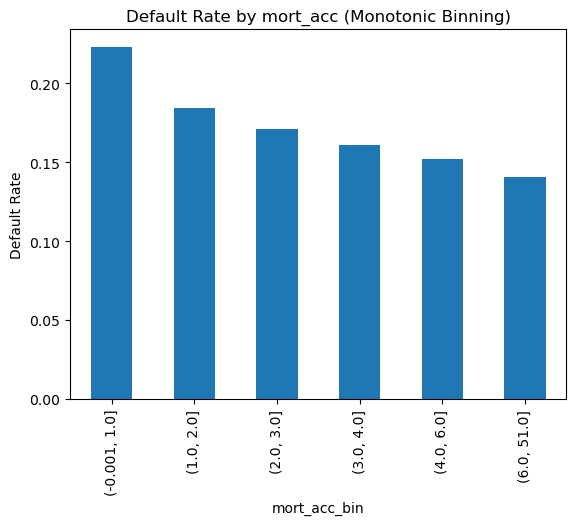

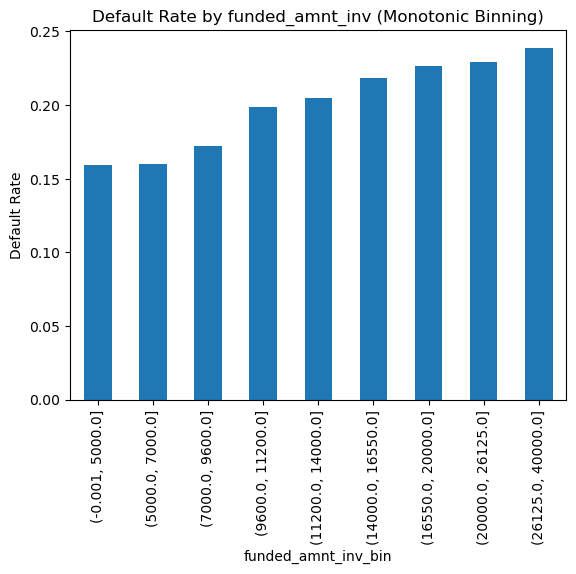

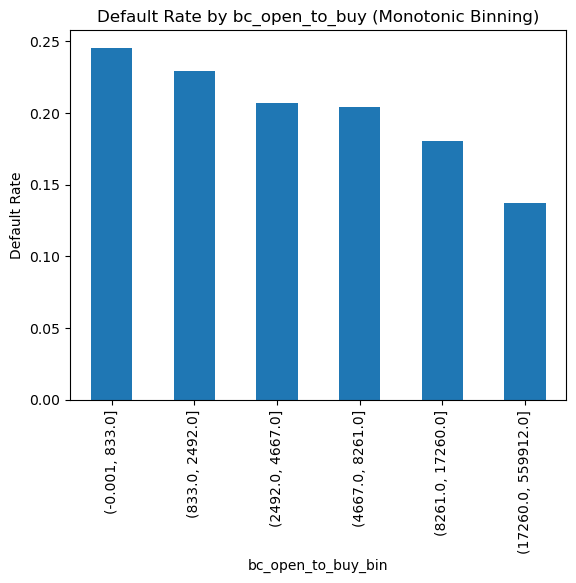

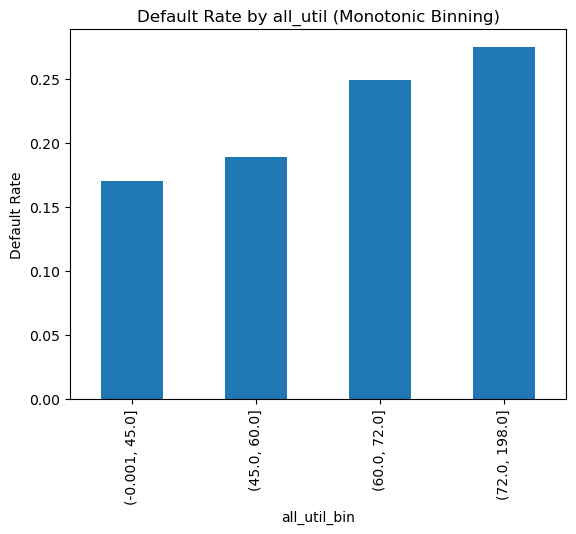

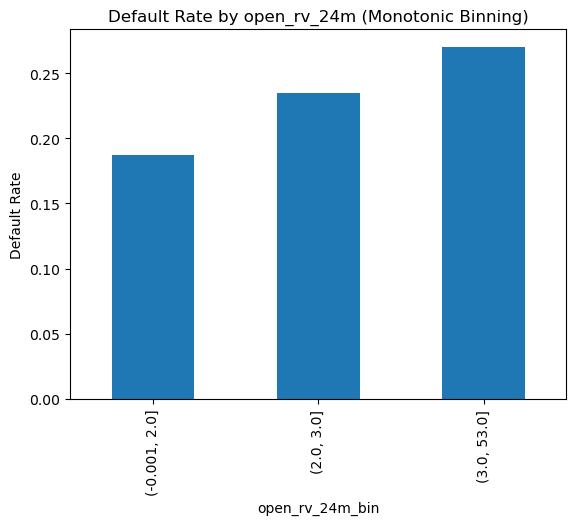

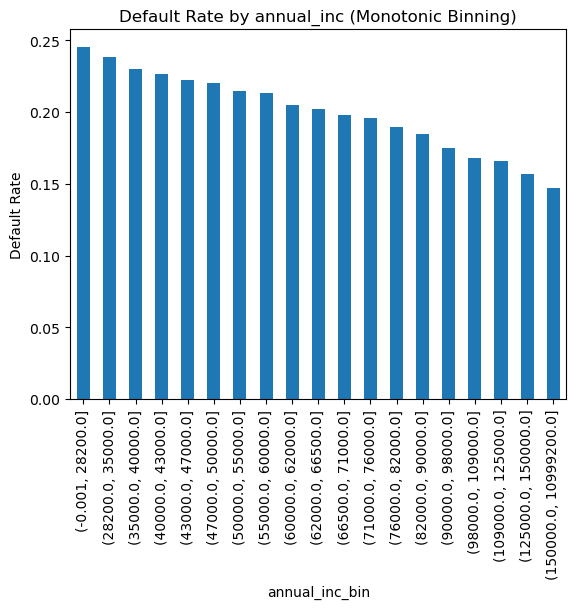

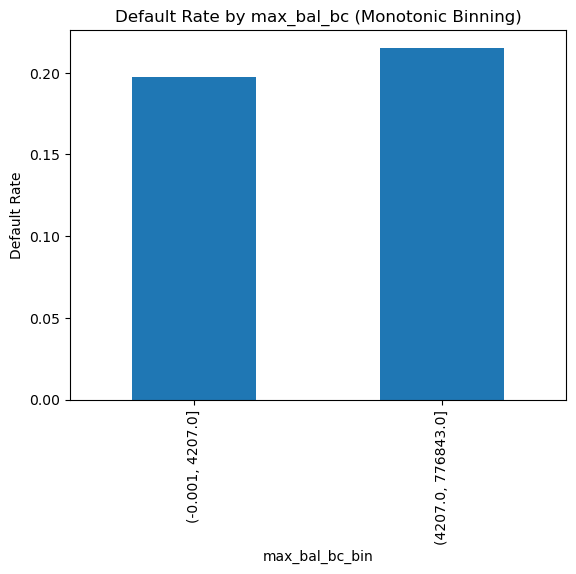

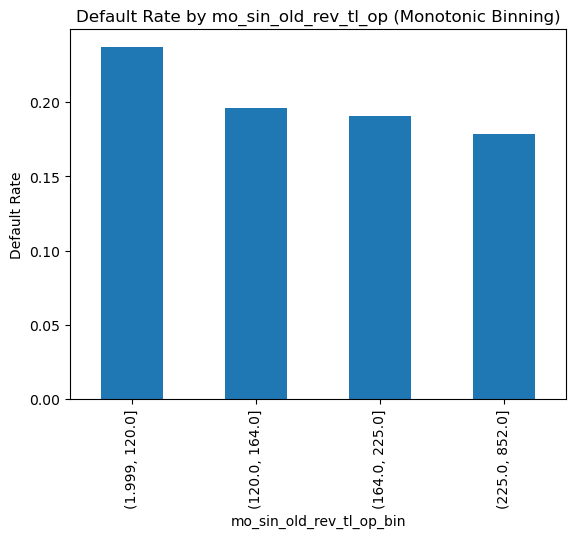

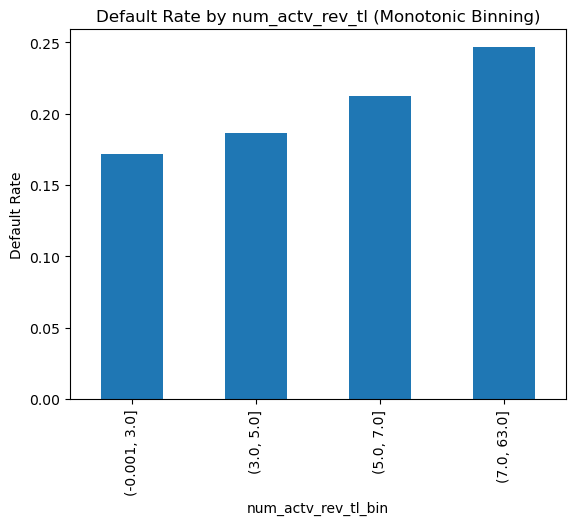

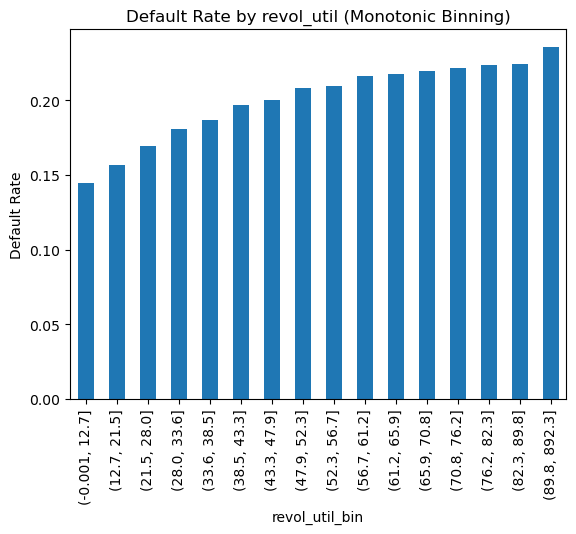

In [19]:

for col in num_cols:

    temp = train_df.groupby(col+"_bin")['target'].mean()

    temp.plot(kind='bar')

    plt.title(f"Default Rate by {col} (Monotonic Binning)")

    plt.ylabel("Default Rate")

    plt.show()

## Proceeded With Monotonic Binning Only

###  IV Calculation

In [20]:
target='target'
iv_dict={}

for col in num_cols:

    table,iv = woe_iv(train_df,col+"_bin",target)

    iv_dict[col]=iv


for col in cat_cols:

    table,iv = woe_iv(train_df,col,target)

    iv_dict[col]=iv

iv_table = pd.DataFrame.from_dict(
iv_dict,orient='index',columns=['IV']
).sort_values(by='IV',ascending=False)

print(iv_table)

                            IV
debt_settlement_flag  1.258770
sub_grade             0.493861
grade                 0.459630
int_rate              0.455581
term                  0.174030
dti                   0.076034
acc_open_past_24mths  0.062421
verification_status   0.056635
bc_open_to_buy        0.050243
tot_hi_cred_lim       0.037157
all_util              0.034146
funded_amnt_inv       0.033224
mort_acc              0.032077
home_ownership        0.031517
annual_inc            0.030328
open_rv_24m           0.029516
num_actv_rev_tl       0.028881
revol_util            0.026578
mo_sin_old_rev_tl_op  0.018285
emp_length            0.011444
max_bal_bc            0.001948


###  Select Variables

In [21]:
selected = iv_table[iv_table['IV']>=0.03].index.tolist()

###  WOE Transformation

In [22]:
for col in selected:

    if col in num_cols:

        table,iv = woe_iv(train_df,col+"_bin",target)

        woe_map = table['WOE'].to_dict()

        train_df[col+"_woe"] = train_df[col+"_bin"].map(woe_map)
        val_df[col+"_woe"] = val_df[col+"_bin"].map(woe_map)

    else:

        table,iv = woe_iv(train_df,col,target)

        woe_map = table['WOE'].to_dict()

        train_df[col+"_woe"] = train_df[col].map(woe_map)
        val_df[col+"_woe"] = val_df[col].map(woe_map)


woe_cols = [c for c in train_df.columns if '_woe' in c]

In [23]:
woe_cols

['debt_settlement_flag_woe',
 'sub_grade_woe',
 'grade_woe',
 'int_rate_woe',
 'term_woe',
 'dti_woe',
 'acc_open_past_24mths_woe',
 'verification_status_woe',
 'bc_open_to_buy_woe',
 'tot_hi_cred_lim_woe',
 'all_util_woe',
 'funded_amnt_inv_woe',
 'mort_acc_woe',
 'home_ownership_woe',
 'annual_inc_woe']

###  Dropping Statistically insignificant variable(grade_woe) after first Logistic model run

In [24]:
woe_cols.remove("grade_woe")


###  Logistic Regression PD Model

In [25]:
X_train = train_df[woe_cols]
y_train = train_df['target']

X_train = sm.add_constant(X_train)

logit = sm.Logit(y_train,X_train)

result = logit.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.417270
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               912546
Model:                          Logit   Df Residuals:                   912531
Method:                           MLE   Df Model:                           14
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.1678
Time:                        21:46:12   Log-Likelihood:            -3.8078e+05
converged:                       True   LL-Null:                   -4.5757e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.3827      0.008   -174.888      0.000      -1.39

###  Validation Scoring

In [26]:
X_val_model = val_df[woe_cols]

X_val_model = sm.add_constant(X_val_model)

val_df['PD'] = result.predict(X_val_model)

### Model Performance

Validation AUC: 0.7488156711391334
Validation Gini: 0.4976313422782668
KS: 0.35310073489368987


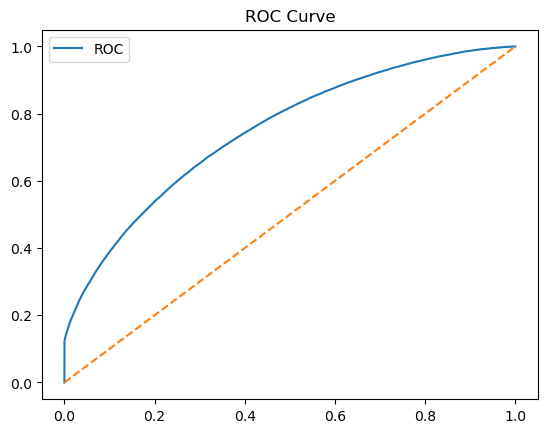

In [27]:
auc = roc_auc_score(val_df['target'],val_df['PD'])

gini = 2*auc-1

print("Validation AUC:",auc)
print("Validation Gini:",gini)

fpr,tpr,_ = roc_curve(val_df['target'],val_df['PD'])

ks = max(tpr-fpr)

print("KS:",ks)

plt.plot(fpr,tpr,label="ROC")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()


###  Score Scaling

In [28]:
PDO = 50

factor = PDO/np.log(2)

base_score = 600

base_odds = 50

offset = base_score - factor*np.log(base_odds)

val_df['score'] = offset - factor*np.log(

val_df['PD']/(1-val_df['PD'])

)

###  Score Distribution

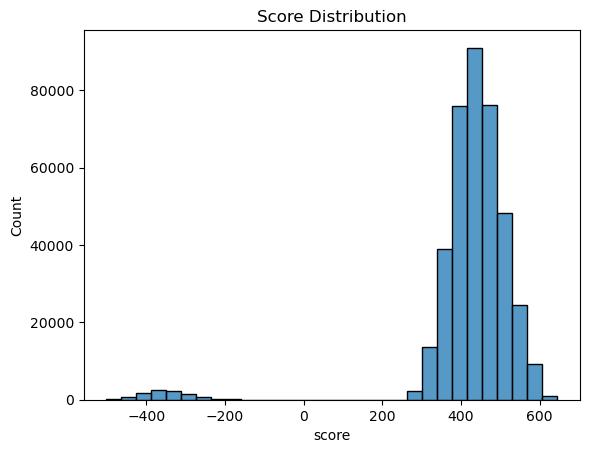

In [29]:
sns.histplot(val_df['score'],bins=30)

plt.title("Score Distribution")

plt.show()

### Risk Bands

risk_band
Very Low     0.008371
Low          0.033400
Medium       0.077229
High         0.148193
Very High    0.350427
Name: target, dtype: float64


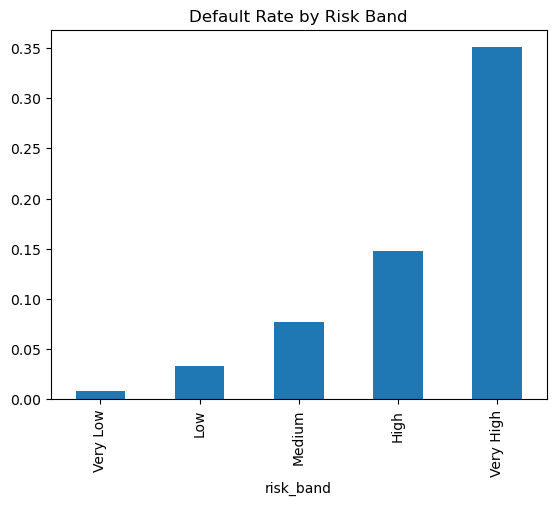

In [30]:
val_df['risk_band'] = pd.cut(

val_df['PD'],

bins=[0,0.02,0.05,0.1,0.2,1],

labels=["Very Low","Low","Medium","High","Very High"]

)

risk_summary = val_df.groupby('risk_band')['target'].mean()

print(risk_summary)

risk_summary.plot(kind='bar')

plt.title("Default Rate by Risk Band")

plt.show()

###  Population Stability Index (PSI)

In [31]:

# Predict PD on Development Sample

X_dev_model = train_df[woe_cols]
X_dev_model = sm.add_constant(X_dev_model)

train_df['PD'] = result.predict(X_dev_model)


# PSI Function

def calculate_psi(expected, actual, bins=10):

    expected_counts, bin_edges = np.histogram(expected, bins=bins)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    psi_values = (actual_perc - expected_perc) * np.log(
        (actual_perc + 1e-6) / (expected_perc + 1e-6)
    )

    psi_table = pd.DataFrame({
        "Bin": range(1, bins+1),
        "Dev %": expected_perc,
        "Val %": actual_perc,
        "PSI": psi_values
    })

    # Add Total PSI row
    total_psi = psi_table["PSI"].sum()

    total_row = pd.DataFrame({
        "Bin": ["Total"],
        "Dev %": [psi_table["Dev %"].sum()],
        "Val %": [psi_table["Val %"].sum()],
        "PSI": [total_psi]
    })

    psi_table = pd.concat([psi_table, total_row], ignore_index=True)

    return total_psi, psi_table


# Calculate PSI

psi_value, psi_table = calculate_psi(

    train_df['PD'],
    val_df['PD'],
    bins=10
)

print("Population Stability Index (PSI):", psi_value)

print("\nPSI Table:")
print(psi_table)

Population Stability Index (PSI): 5.653073424123176e-05

PSI Table:
      Bin     Dev %     Val %           PSI
0       1  0.318198  0.318940  1.731231e-06
1       2  0.328165  0.326304  1.058448e-05
2       3  0.189982  0.190656  2.388692e-06
3       4  0.086425  0.087110  5.403163e-06
4       5  0.038105  0.037753  3.270560e-06
5       6  0.012581  0.012654  4.226310e-07
6       7  0.001913  0.002076  1.330520e-05
7       8  0.000042  0.000074  1.842224e-05
8       9  0.000000  0.000000  0.000000e+00
9      10  0.024588  0.024432  1.002537e-06
10  Total  1.000000  1.000000  5.653073e-05


### PSI Visualization

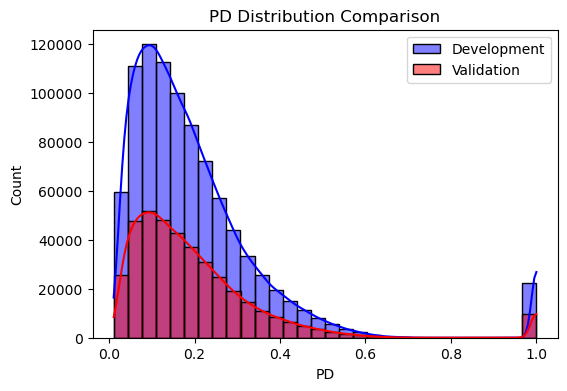

In [32]:


plt.figure(figsize=(6,4))

sns.histplot(train_df['PD'], color='blue', label='Development', bins=30, kde=True)

sns.histplot(val_df['PD'], color='red', label='Validation', bins=30, kde=True)

plt.title("PD Distribution Comparison")

plt.legend()

plt.show()


### REJECT INFERENCING – PARCELING METHOD



### Simulate Reject Population
Example: applicants with PD > 0.15


In [33]:

reject_df = val_df[val_df['PD'] > 0.15].copy()

print("Simulated Reject Population:", reject_df.shape)

Simulated Reject Population: (208286, 54)



#### Score Rejects Using Existing Model


In [34]:
reject_df['score_band'] = pd.qcut(
    reject_df['PD'],
    10,
    duplicates='drop'
)


### Calculate Default Rate by Score Band


In [35]:
band_default = val_df.groupby(
    pd.qcut(val_df['PD'],10,duplicates='drop')
)['target'].mean()

print("Default Rate by Score Band")
print(band_default)


Default Rate by Score Band
PD
(0.0098, 0.0538]    0.034518
(0.0538, 0.0798]    0.068987
(0.0798, 0.105]     0.093278
(0.105, 0.131]      0.118540
(0.131, 0.16]       0.148124
(0.16, 0.192]       0.177069
(0.192, 0.231]      0.210361
(0.231, 0.282]      0.251093
(0.282, 0.371]      0.321537
(0.371, 1.0]        0.583840
Name: target, dtype: float64



### Assign Inferred Default to Rejects



In [36]:
# Map band default rate
reject_df['inferred_default_prob'] = reject_df['score_band'].map(band_default)

# Replace missing probabilities with overall default rate
overall_default_rate = val_df['target'].mean()

reject_df['inferred_default_prob'] = reject_df['inferred_default_prob'].fillna(
    overall_default_rate
)

# Ensure probabilities are within [0,1]
reject_df['inferred_default_prob'] = reject_df['inferred_default_prob'].clip(0,1)

# Random assignment of inferred default
np.random.seed(42)

reject_df['target_inferred'] = np.random.binomial(
    1,
    reject_df['inferred_default_prob']
)

print(reject_df[['PD','score_band','inferred_default_prob','target_inferred']].head())

               PD      score_band  inferred_default_prob  target_inferred
1254233  0.276992  (0.274, 0.311]               0.200735                0
1717675  0.212587  (0.202, 0.222]               0.200735                1
1247364  0.999885    (0.458, 1.0]               0.200735                0
1660556  0.150990  (0.149, 0.166]               0.200735                0
527359   0.533195    (0.458, 1.0]               0.200735                0



### Combine Accepted and Inferred Rejects


In [37]:
accepted_df = train_df.copy()

accepted_df['target_final'] = accepted_df['target']

reject_df_model = reject_df[woe_cols].copy()

reject_df_model['target_final'] = reject_df['target_inferred']

augmented_df = pd.concat(
    [accepted_df[woe_cols + ['target_final']], reject_df_model],
    axis=0
)

print("Augmented Dataset Shape:", augmented_df.shape)

Augmented Dataset Shape: (1120832, 15)



### Retrain Logistic Model with Augmented Data


In [38]:
X_aug = augmented_df[woe_cols]
y_aug = augmented_df['target_final']

X_aug = sm.add_constant(X_aug)

logit_aug = sm.Logit(y_aug,X_aug)

result_aug = logit_aug.fit()

print(result_aug.summary())

Optimization terminated successfully.
         Current function value: 0.449782
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           target_final   No. Observations:              1120832
Model:                          Logit   Df Residuals:                  1120817
Method:                           MLE   Df Model:                           14
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                  0.1032
Time:                        21:46:23   Log-Likelihood:            -5.0413e+05
converged:                       True   LL-Null:                   -5.6212e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.5223      0.003   -575.434      0.000      -1.528


### Compare Model Performance


In [39]:
val_df['PD_augmented'] = result_aug.predict(X_val_model)

auc_aug = roc_auc_score(val_df['target'], val_df['PD_augmented'])

gini_aug = 2*auc_aug - 1

print("Original Model AUC:", auc)
print("Reject Inference Model AUC:", auc_aug)

print("Original Model Gini:", gini)
print("Reject Inference Model Gini:", gini_aug)

Original Model AUC: 0.7488156711391334
Reject Inference Model AUC: 0.7487101944062611
Original Model Gini: 0.4976313422782668
Reject Inference Model Gini: 0.49742038881252215



### ROC Curve Comparison


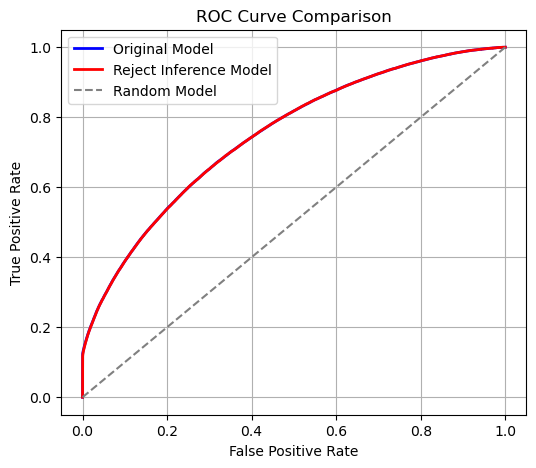

In [41]:
fpr2, tpr2, _ = roc_curve(val_df['target'], val_df['PD_augmented'])

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, color='blue', linewidth=2, label="Original Model")
plt.plot(fpr2, tpr2, color='red', linewidth=2, label="Reject Inference Model")

plt.plot([0,1],[0,1], linestyle='--', color='gray', label="Random Model")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

### Reject Inference Method Used

The Reject Inference method implemented in this notebook is the **Parceling Method**.

This technique is widely used in traditional credit scorecard modeling and is described in credit risk modeling literature by experts such as Naeem Siddiqi.

